In [1]:
## HR Data Report
## In this project I am simulating being provided HR data and being requested to finding out the following:

## what is the distribution of Employee Status

## what is the distribution of work modes amongst employees

## how many employees are there in there in each department 

## average salary by department 

## which job title has the highest avarage salary

## What is the average salary in different Departments based on Job Title ?

## How many employees Resigned & Terminated in each department ?

## How does salary vary with years of experience ?

## What is the average performance rating by department ?

## Which Country have the highest concentration of employees ?

## Is there a correlation between performance rating and salary ?

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
company_data = pd.read_csv('hr_data.zip').drop('Unnamed: 0', axis=1)
company_data

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
0,EMP0000001,Joshua Nguyen,IT,Software Engineer,2011-08-10,"Isaacland, Denmark",5,14,Resigned,On-site,1585363
1,EMP0000002,Julie Williams,Marketing,SEO Specialist,2018-03-02,"Anthonyside, Costa Rica",2,7,Active,On-site,847686
2,EMP0000003,Alyssa Martinez,HR,HR Manager,2023-03-20,"Port Christinaport, Saudi Arabia",1,2,Active,On-site,1430084
3,EMP0000004,Nicholas Valdez,IT,Software Engineer,2023-10-12,"Port Shelbychester, Antigua and Barbuda",1,1,Active,On-site,990689
4,EMP0000005,Joel Hendricks,Operations,Logistics Coordinator,2024-12-09,"Lake Kimberly, Palestinian Territory",5,0,Active,On-site,535082
...,...,...,...,...,...,...,...,...,...,...,...
1999995,EMP1999996,Cody Russell,Operations,Logistics Coordinator,2010-08-31,"Casefurt, Serbia",3,14,Active,Remote,657648
1999996,EMP1999997,Tracey Smith,IT,Software Engineer,2021-05-07,"Dannyport, Kuwait",3,4,Active,On-site,1030109
1999997,EMP1999998,Tracy Lee,Sales,Business Development Manager,2024-05-29,"Craighaven, Nigeria",5,1,Active,Remote,1313085
1999998,EMP1999999,Michael Roberson,IT,Software Engineer,2023-02-14,"Jonathanmouth, Djibouti",4,2,Retired,On-site,1479727


In [4]:
company_data.isnull().sum()

Employee_ID           0
Full_Name             0
Department            0
Job_Title             0
Hire_Date             0
Location              0
Performance_Rating    0
Experience_Years      0
Status                0
Work_Mode             0
Salary_INR            0
dtype: int64

In [5]:
#EMP_Status_percentage = (company_data['Status'].value_counts() / len(company_data['Status'])*100).round(1)
#EMP_Status_percentage

#EMP_Status_percentage = (company_data['Status'].value_counts(normalize=True) * 100).round(1).astype(str) + '%'
#EMP_Status_percentage

status_dist = pd.DataFrame({
    'Count': company_data['Status'].value_counts(),
    'Percentage': (company_data['Status'].value_counts(normalize=True) * 100).round().astype(str) + '%'
})
status_dist

,Count,Percentage
Active,1401558,70.0%
Resigned,398660,20.0%
Retired,99912,5.0%
Terminated,99870,5.0%


In [6]:
#company_data['Work_Mode'].value_counts()

work_enviroment = (company_data['Work_Mode'].value_counts()/ len(company_data['Work_Mode'])*100).round(1).astype(str) + '%'
work_enviroment

On-site    60.0%
Remote     40.0%
Name: Work_Mode, dtype: object

In [7]:
emp_per_dep = company_data.groupby('Department')['Employee_ID'].size().reset_index(name='Employee_Count')
emp_per_dep

,Department,Employee_Count
0,Finance,199873
1,HR,159119
2,IT,601042
3,Marketing,240081
4,Operations,300095
5,R&D,99759
6,Sales,400031


In [28]:
avg_salary = company_data.groupby('Department')['Salary_INR'].mean().round(2).reset_index(name='Average_Salary')
avg_salary

,Department,Average_Salary
0,Finance,940411.74
1,HR,743853.56
2,IT,1129858.15
3,Marketing,769936.15
4,Operations,754626.25
5,R&D,800377.16
6,Sales,792957.86


In [30]:
company_data[company_data['Salary_INR'] == company_data['Salary_INR'].max()]

,Employee_ID,Full_Name,Department,Job_Title,Hire_Date,Location,Performance_Rating,Experience_Years,Status,Work_Mode,Salary_INR
1697605,EMP1697606,Kathryn Owens,IT,IT Manager,2018-02-22,"Adamsborough, Greenland",5,7,Active,Remote,2999976


In [45]:
top_titles = company_data.groupby('Job_Title')['Salary_INR'].max().sort_values(ascending=False).head(3).round(2).reset_index(name='Top_Salary')
top_titles

,Job_Title,Top_Salary
0,IT Manager,2999976
1,Finance Manager,2499958
2,Software Engineer,1799994


In [42]:
avg_salary_by_dept_and_title = company_data.groupby(['Department','Job_Title'])['Salary_INR'].mean().round(2).reset_index(name='Average_Salary')
avg_salary_by_dept_and_title

,Department,Job_Title,Average_Salary
0,Finance,Accountant,650076.48
1,Finance,CFO,795015.87
2,Finance,Finance Manager,1743241.53
3,Finance,Financial Analyst,1051522.90
4,HR,HR Director,800694.44
5,HR,HR Executive,550548.86
6,HR,HR Manager,1252401.91
7,HR,Talent Acquisition Specialist,801422.24
8,IT,CTO,801402.75
9,IT,Data Analyst,800996.38


In [47]:
non_employee = company_data[company_data['Status'].apply(lambda x: x in ['Resigned', 'Terminated'])].groupby('Department')['Status'].value_counts()
non_employee

Department  Status    
Finance     Resigned       40238
            Terminated      9988
HR          Resigned       31736
            Terminated      7861
IT          Resigned      119852
            Terminated     29881
Marketing   Resigned       47793
            Terminated     12044
Operations  Resigned       59397
            Terminated     14884
R&D         Resigned       19919
            Terminated      4998
Sales       Resigned       79725
            Terminated     20214
Name: Status, dtype: int64

In [48]:
exp_vs_salary = company_data.groupby('Experience_Years')['Salary_INR'].mean().round(2)
exp_vs_salary

Experience_Years
0     896737.45
1     895903.76
2     896755.65
3     896861.25
4     897944.57
5     896484.08
6     896012.63
7     895722.67
8     897148.36
9     898482.94
10    895662.03
11    901452.75
12    896432.93
13    898790.20
14    895610.79
15    895647.40
Name: Salary_INR, dtype: float64

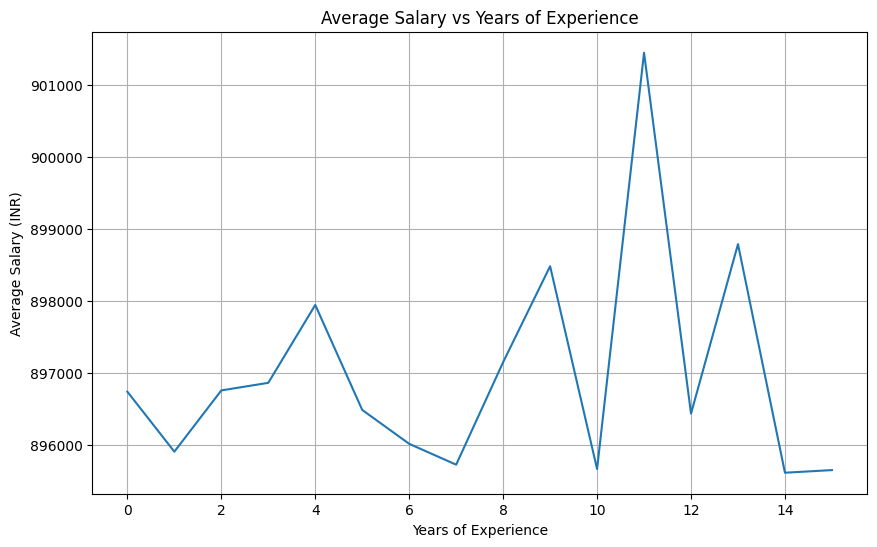

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(exp_vs_salary.index, exp_vs_salary.values)
plt.title('Average Salary vs Years of Experience')
plt.xlabel('Years of Experience')
plt.ylabel('Average Salary (INR)')
plt.grid(True)
plt.show()

In [50]:
avg_performance_per_dept = company_data.groupby('Department')['Performance_Rating'].mean()
avg_performance_per_dept

Department
Finance       2.996818
HR            2.995670
IT            2.998216
Marketing     3.004736
Operations    2.996081
R&D           3.001885
Sales         3.006362
Name: Performance_Rating, dtype: float64

In [51]:
country_emp_count = company_data['Location'].value_counts()
country_emp_count.head(5)

Lake Michael, Congo                                                   20
New Christopher, Congo                                                19
East Michael, Congo                                                   17
West Michael, Sao Tome and Principe                                   16
South Michael, British Indian Ocean Territory (Chagos Archipelago)    16
Name: Location, dtype: int64

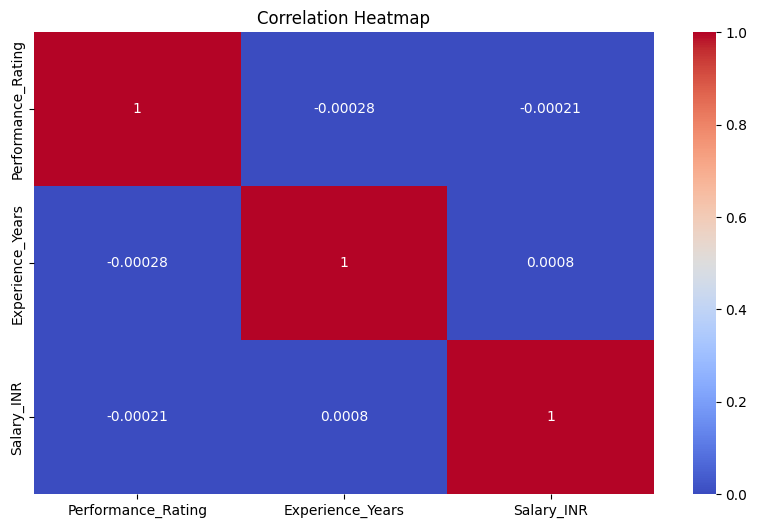

In [57]:
plt.figure(figsize=(10, 6))

sns.heatmap(company_data.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()